<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# Construcción de una Agente de Reflexión con LangGraph

En este proyecto guiado, aprenderás a crear agentes de reflexión utilizando LangGraph, una potente herramienta para desarrollar sistemas de IA con capacidad de autoaprendizaje. Los agentes de reflexión representan un avance significativo en las capacidades de la IA: pueden evaluar sus propios resultados, identificar debilidades y mejorar de forma iterativa mediante ciclos de retroalimentación. Comenzarás comprendiendo el concepto de reflexión en IA y, a continuación, crearás un agente de reflexión completo capaz de generar contenido, evaluar su calidad y refinar los resultados mediante múltiples iteraciones. Trabajando con un generador de publicaciones de LinkedIn como ejemplo, implementarás un flujo de trabajo basado en grafos que imita el pensamiento reflexivo humano, permitiendo al agente transformar contenido básico en resultados pulidos y atractivos. Al finalizar este proyecto, tendrás experiencia práctica en la creación de sistemas de IA capaces de analizar críticamente su propio trabajo y mejorar continuamente su rendimiento.

## __Table of Contents__

<ol>
    <li>
        <ol>
            <li><a href="#Installing-Required-Libraries">Installing Required Libraries</a></li>
        </ol>
    </li>
    <li>
        <a href="#What-is-Reflection?">What is Reflection?</a>
    </li>
    <li>
        <a href="#Workflow-of-Reflection-Agent-in-LangGraph:">Workflow of Reflection Agent in LangGraph</a>
    </li>
    <li>
        <a href="#Building-an-Optimized-LinkedIn-Post-Generator-with-a-Reflection-Agent">Building an Optimized LinkedIn Post Generator with a Reflection Agent</a>
        <ol>
            <li><a href="#Instantiating-the-Language-Model">Instantiating the Language Model</a></li>
            <li><a href="#Generation-Prompt-for-Posts">Generation Prompt for Posts</a></li>
            <li><a href="#Creating-the-Chain-for-LinkedIn-Post-Generation">Creating the Chain for LinkedIn Post Generation</a></li>
            <li><a href="#Reflection-Prompt-for-LinkedIn-Post-Critique">Reflection Prompt for LinkedIn Post Critique</a></li>
            <li><a href="#Creating-the-Reflect-Chain">Creating the Reflect Chain</a></li>
            <li><a href="#Defining-the-Agent-State-for-Reflection-Agent">Defining the Agent State for Reflection Agent</a></li>
            <li><a href="#Defining-the-Generation-and-Reflection--Node">Defining the Generation and Reflection Node</a></li>
            <li><a href="#Why-HumanMessage?">Why HumanMessage?</a></li>
            <li><a href="#Adding-the-Generate-Node-to-the-Graph">Adding the Generate Node to the Graph</a></li>
            <li><a href="#Adding-the-Reflect-Node-to-the-Graph">Adding the Reflect Node to the Graph</a></li>
            <li><a href="#Setting-the-Entry-Point-in-the-Graph">Setting the Entry Point in the Graph</a></li>
            <li><a href="#Adding-a-Router-Node-for-Decision-Making">Adding a Router Node for Decision Making</a></li>
            <li><a href="#Compiling-the-Workflow">Compiling the Workflow</a></li>
            <li><a href="#Defining-Inputs-for-the-Workflow">Defining Inputs for the Workflow</a></li>
            <li><a href="#Executing-the-Workflow">Executing the Workflow</a></li>
            <li><a href="#Plotting-the-Graph">Plotting the Graph</a></li>
        </ol>
    </li>
</ol>


## 1. Objetivos

Tras completar este laboratorio, podrá:

- Crear agentes de IA con capacidad de reflexión utilizando la estructura de flujo de trabajo basada en grafos de LangGraph.

- Implementar un proceso de varios pasos para generar, evaluar y refinar contenido producido por IA.

- Diseñar flujos de trabajo conversacionales con gestión del estado de los mensajes para una mejor retención del contexto.

- Crear lógica de enrutamiento condicional para controlar el comportamiento del agente y los procesos de iteración.

- Aplicar técnicas de reflexión para mejorar la calidad y precisión del contenido generado por IA.

- Desarrollar sistemas de autoaprendizaje capaces de identificar y abordar sus propias limitaciones.

## 2. Configuración


Para este laboratorio, utilizaremos las siguientes bibliotecas:

* [`langgraph`](https://python.langchain.com/docs/langgraph) para la creación de flujos de trabajo y grafos basados ​​en estados para sistemas de agentes complejos.

* [`langchain-ibm`](https://python.langchain.com/docs/integrations/llms/ibm_watsonx) para la integración con los modelos base WatsonX de IBM.

* [`langchain`](https://python.langchain.com/docs/get_started/introduction) para la creación de aplicaciones y flujos de trabajo basados ​​en LLM.

* [`langchain_community`](https://python.langchain.com/docs/integrations/providers/) para integraciones adicionales con diversas herramientas y servicios.

* [`pygraphviz`](https://pygraphviz.github.io/) para la visualización y representación de grafos creados con LangGraph.

### *3.1. Instalación de las Bibliotecas Necesarias*

Las siguientes bibliotecas necesarias no están preinstaladas en el su entorno. Debe ejecutar la siguiente celda para instalarlas. Este paso puede tardar varios minutos, tenga paciencia.

```bash
pip install -r requirements.txt
```

### *3.2. Importación de las Bibliotecas Necesarias*

Importa aquí todas las bibliotecas necesarias:

In [1]:
from langchain_ibm import ChatWatsonx
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import END, MessagesState, StateGraph

from typing import List, Sequence
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

### *3.3. Aviso Legal Sobre la API*

Este laboratorio utiliza módulos LLM proporcionados por OpenAI. Este entorno se ha configurado para permitir el uso de LLM sin claves API, de modo que pueda solicitarlos **gratis (con limitaciones)**. Por lo tanto, si desea ejecutar este cuaderno **localmente fuera** del entorno JupyterLab de Skills Network, deberá configurar sus propias claves API. Tenga en cuenta que el uso de sus propias claves API implicará cargos personales.

Si ejecuta este laboratorio localmente, deberá configurar sus propias claves API. Este laboratorio utiliza los módulos `ChatOpenAI` y `ChatWatsonx` de `langchain`. La siguiente sección muestra ambas configuraciones con instrucciones. **Reemplace todas las instancias** de ambos módulos con los módulos completos que se muestran a continuación en todo el laboratorio.

<p style='color: red'><b>NO ejecute la siguiente celda si no está ejecutando el laboratorio localmente, ya que provocará errores.</b>

In [2]:
from langchain_openai import ChatOpenAI

llm_openai = ChatOpenAI(
    model= "gpt-4o-mini",
    temperature= 0.4,
    max_completion_tokens= 2048
)

## 4. ¿Qué es la Reflexión?

La reflexión es una estrategia de inducción que busca mejorar la calidad y precisión de los resultados generados por agentes de IA. Consiste en lograr que el agente **pause, revise y critique** sus propios resultados antes de finalizarlos. Este proceso iterativo ayuda a reducir errores y a mejorar el rendimiento con el tiempo.

Por ejemplo, cuando un modelo de IA genera código, normalmente produce el resultado instantáneamente. Sin embargo, al igual que los programadores humanos, el código necesita ser probado y perfeccionado. La reflexión garantiza que el agente de IA **evalúe el código generado, identifique posibles errores e itere** para corregirlos. Esto imita la forma en que los desarrolladores escriben, prueban, depuran y optimizan su trabajo, lo que resulta en resultados más fiables.

Una analogía sencilla sería compararlo con dos sistemas:
- **Sistema 1**: reactivo e instintivo (respuestas iniciales rápidas).

- **Sistema 2**: reflexivo y deliberativo (revisión y perfeccionamiento cuidadosos de los resultados).

Los agentes de reflexión animan a la IA a funcionar más como el **Sistema 2**, iterando sobre su trabajo hasta alcanzar la calidad deseada.

## 5. Flujo de Trabajo de la Agente de Reflexión en LangGraph

1. **Nodo de Generación: Generar Resultado Inicial**

- El primer paso del proceso es el **nodo de generación**, que produce rápidamente un resultado inicial a partir de la consigna dada. Esta etapa se centra en generar un primer borrador sin buscar la perfección. Actúa como una respuesta instintiva, proporcionando una versión preliminar del resultado. Por ejemplo, si la tarea es escribir una publicación para LinkedIn, el nodo de generación propondría una idea básica. Este borrador se pasa al siguiente paso para su evaluación.

<br>

2. **Nodo de Evaluación: Evaluar la Calidad del Resultado**

- Una vez generado el resultado inicial, el **nodo de evaluación** analiza su calidad. Este paso consiste en comprobar si el resultado es suficientemente bueno o si necesita mejoras. La evaluación se centra en aspectos clave como la claridad, el atractivo y la relevancia del mensaje. Por ejemplo, en el caso de una publicación de LinkedIn, la evaluación podría determinar si la publicación resulta auténtica, si se ajusta a un tono profesional o si omite información importante. Si el resultado se considera aceptable, pasa al paso final.

<br>

3. **Nodo de Reflexión: Crítica y Refinamiento**

- Si el nodo de evaluación determina que el resultado necesita mejoras, el **nodo de reflexión** interviene para refinar el contenido. Este paso es más reflexivo y minucioso, ya que el sistema analiza el resultado y busca maneras de mejorarlo. El nodo de reflexión critica el borrador, sugiere cambios y revisa el contenido para perfeccionarlo. Esto puede incluir mejorar el tono, añadir claridad, destacar logros o hacer que la publicación sea más atractiva. El sistema continúa refinando el resultado mediante este proceso hasta alcanzar el nivel de calidad deseado.

<br>

4. **Resultado Final: Presentación del Resultado Refinado**

- Una vez que el nodo de reflexión ha completado su función, se genera el resultado final. Este es el resultado de los procesos de reflexión y evaluación, donde el borrador inicial se ha refinado y mejorado. El agente presenta ahora la versión final del contenido: una publicación de LinkedIn pulida y de alta calidad, lista para su publicación. Tras este paso, el proceso concluye y se entrega la respuesta final al usuario.

**Ejemplo (Generación de publicación en LinkedIn):**
Imagina pedirle a una IA que escriba una publicación en LinkedIn anunciando un ascenso:

**Indicación:**
"Escribe una publicación en LinkedIn anunciando mi ascenso a Gerente de Ingeniería."

**Resultado inicial de la IA (Sistema 1):**
*"¡Me emociona compartir que he sido ascendido a Gerente de Ingeniería!"*

**Paso de reflexión:**
La IA revisa la publicación y pregunta:
*"¿Esta publicación destaca el crecimiento del liderazgo o expresa gratitud?"*

**Resultado refinado (Sistema 2):**
*"¡Me entusiasma compartir que he sido ascendido a Gerente de Ingeniería en [Empresa]! Agradezco la mentoría, la colaboración del equipo y las oportunidades que me han llevado a este momento. Tengo muchas ganas de liderar nuevas iniciativas y seguir creciendo con este increíble equipo. #Liderazgo #CrecimientoProfesional #GerenteDeIngeniería"*

### *5.1. Creación de un Generador de Publicaciones Optimizado para LinkedIn con un Agente de Reflexión*

En este proceso, buscamos mejorar la calidad de las publicaciones generadas por IA mediante un agente de reflexión. La idea es permitir que la IA genere una publicación y luego la revise, refinando el contenido de forma iterativa en función de la retroalimentación. Este enfoque ayuda a mejorar la interacción, la relevancia y el tono, garantizando un mejor resultado final.

Construiremos un sistema que incluye una fase de generación, donde se crea la publicación, seguida de una fase de reflexión, donde la IA revisa y refina el resultado. Este ciclo garantiza que la IA produzca contenido de mayor calidad.

El siguiente diagrama ilustra el flujo de trabajo de este sistema, mostrando la interacción entre los nodos de generación y reflexión.

<div style="text-align: center;">
  <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Cbuc3z8N1_Ew2ESw199Slw/Workflow.png" alt="Workflow" style="width: 40%; height: 500px;">
</div>


### *5.2. Instanciación del Modelo de Lenguaje*

Este paso inicializa el modelo de lenguaje **`ChatOpenAI`**, que se utilizará para generar respuestas basadas en las indicaciones.

In [3]:
from langchain_openai import ChatOpenAI

llm_openai = ChatOpenAI(
    model= "gpt-4o-mini",
    temperature= 0.4,
    max_completion_tokens= 2048
)

### *5.3. Generación de Publicaciones*

En esta sección, creamos una herramienta para generar publicaciones en LinkedIn. El asistente se encarga de crear publicaciones de alta calidad a partir de la información proporcionada por el usuario. Además, si el usuario ofrece comentarios o críticas, el asistente revisa el contenido de la publicación según corresponda.

Utilizamos **`ChatPromptTemplate`** de LangChain para estructurar la solicitud. 

Esta consta de dos partes principales:

**1. Mensaje del sistema**

- Este mensaje proporciona instrucciones al asistente sobre su función y tarea.

- En este caso, el asistente se presenta como un **asistente profesional de contenido para LinkedIn**, cuya función es generar la mejor publicación posible en LinkedIn a partir de la información proporcionada por el usuario.

- También especifica que, si el usuario proporciona comentarios o críticas, el asistente debe revisar la publicación para mejorar su claridad, tono o interacción.

**2. Marcador de posición del mensaje**

- Este campo se utiliza para insertar el contenido o mensaje en el que se basará la publicación.

- El marcador de posición se completará con la solicitud del usuario durante la ejecución.

In [59]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt_generacion = ChatPromptTemplate.from_messages(
    [
        (
            "system", "Tu eres un asistente profesional de contenido para LinkedIn encargado de crear publicaciones atractivas, perspicaces y bien estructuradas en LinkedIn."
            " Genera la mejor publicación posible en LinkedIn para la solicitud del usuario."
            " Si el usuario proporciona comentarios o críticas, responde con una versión refinada de tus intentos anteriores, mejorando la claridad, el tono o la interacción según sea necesario.",
        ),
        MessagesPlaceholder(variable_name= "mensajes")
    ]
)

### *5.4. Creación de la Cadena para la Generación de Publicaciones en LinkedIn*

En este paso, combinamos la **`prompt_generacion`** con un modelo de lenguaje (LLM) para formar una cadena completa que permitirá al sistema generar publicaciones en LinkedIn a partir de la entrada del usuario.

La **`cadena_generacion`** enlaza la **`prompt_generacion`** con el **LLM** (Modelo de Lenguaje Grande), lo que permite al sistema generar una publicación profesional en LinkedIn tras procesar la entrada del usuario a través de la solicitud.

- **`prompt_generacion`**: Esta es la plantilla que guía al modelo sobre cómo generar la publicación en LinkedIn, incluyendo el mensaje del sistema y el marcador de posición para la entrada del usuario.

- **`llm`**: Este es el modelo de lenguaje que toma la solicitud y produce la publicación a partir de la entrada proporcionada.

Mediante el operador de tubería (`|`), encadenamos estos componentes para que la solicitud fluya sin problemas hacia el modelo de lenguaje y este genere la publicación final en LinkedIn.

In [60]:
cadena_generacion = prompt_generacion | llm_openai

### *5.5. Indicación de Reflexión para la Crítica de una Publicación de LinkedIn*

En este paso, definimos la **`indicación de reflexión`**, una plantilla que se utiliza para generar críticas y recomendaciones que permitan mejorar una publicación de LinkedIn. Esta indicación guía al modelo para evaluar la calidad de la publicación y proporcionar comentarios estructurados y prácticos.

- **`indicación de reflexión`**: El mensaje del sistema indica al modelo que actúe como un estratega de contenido profesional de LinkedIn. El modelo evaluará la publicación en función de factores como el tono, la estructura, la claridad, el potencial de interacción, el formato y la relevancia. A continuación, generará comentarios para ayudar a mejorar la efectividad general de la publicación y su alineación con las mejores prácticas de LinkedIn.

In [61]:
prompt_reflexion = ChatPromptTemplate.from_messages([
    (
        "system",
        """Eres un estratega de contenido profesional de LinkedIn y experto en liderazgo de opinión. Tu tarea consiste en evaluar críticamente la publicación de LinkedIn proporcionada y ofrecer una crítica exhaustiva. Sigue estas pautas:

        1. Evalúa la calidad general de la publicación, su profesionalismo y su alineación con las mejores prácticas de LinkedIn.
        2. Evalúa la estructura, el tono, la claridad y la legibilidad de la publicación.
        3. Analiza el potencial de interacción de la publicación (me gusta, comentarios, compartidos) y su efectividad para construir credibilidad profesional.
        4. Considera la relevancia de la publicación para el sector del autor, su audiencia o las tendencias actuales.
        5. Examina el uso del formato (por ejemplo, saltos de línea, viñetas), hashtags, menciones y contenido multimedia (si lo hay).
        6. Evalúa la efectividad de cualquier llamada a la acción o conclusión.

        Proporciona una crítica detallada que incluya:
        - Una breve explicación de las fortalezas y debilidades de la publicación.
        - Áreas específicas que podrían mejorarse.
        - Sugerencias prácticas para mejorar la claridad, la interacción y el profesionalismo.

        Tu crítica se utilizará para mejorar la publicación en la siguiente revisión, así que asegúrate de que tus comentarios sean reflexivos, constructivos y prácticos.
        """
    ),
    MessagesPlaceholder(variable_name= "mensajes")
])

### *5.6. Creación de la Cadena de Reflexión*

La **`cadena_reflexion`** se crea combinando la **`prompt_reflexion`** con el modelo de lenguaje (LLM). Esta cadena permite que el modelo evalúe la publicación generada y proporcione retroalimentación.

In [62]:
cadena_reflexion = prompt_reflexion | llm_openai

### *5.7. Definición del Estado del Agente para el Agente de Reflexión*

Al crear un flujo de trabajo conversacional desde cero, el **estado** representa el contexto en constante evolución de la conversación o tarea. Registra las interacciones entre el usuario y la IA, y crece dinámicamente a medida que se añaden nuevos mensajes.

Si definiéramos el estado manualmente, se vería así:

#### 5.7.1. Definición manual del estado

Usando `TypedDict` de Python, podemos definir un estado que contenga una lista de mensajes:

```python
from typing import TypedDict, List, Annotated
from langchain.schema import HumanMessage, AIMessage, SystemMessage

# Definir el estado con TypedDict.
class EstadoAgente(TypedDict):
    mensajes: Annotated[List[HumanMessage | AIMessage | SystemMessage], "agregar_mensajes"]
```

En esta configuración:
- **`HumanMessage`**: Representa las entradas o indicaciones del usuario.

- **`AIMessage`**: Representa las respuestas generadas por IA.

- **`SystemMessage`**: Representa las instrucciones del sistema, como la retroalimentación para el refinamiento o los criterios de evaluación.

- **`agregar_mensajes`**: Garantiza que los nuevos mensajes se añadan a la lista, conservando el contexto necesario para las interacciones iterativas.

Si bien este enfoque es flexible, requiere la gestión manual del estado, incluyendo la creación de flujos de trabajo y el mantenimiento de la lista de mensajes.

#### 5.7.2. Inicializando `MessageGraph`

Para agilizar la creación de flujos de trabajo y la gestión del estado, LangGraph ofrece una solución predefinida llamada `MessageGraph`. Esta simplifica el proceso de configuración de flujos de trabajo conversacionales al gestionar automáticamente la estructura subyacente.

In [102]:
from langgraph.graph import StateGraph, MessagesState
from typing import List, Annotated, TypedDict, Sequence
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage

# Iniciando predefinición del estado del agente usando TypedDict.
grafo = StateGraph(MessagesState)

Detrás de escena:

- A medida que el usuario interactúa con el agente, se agrega un **`HumanMessage`** al estado.

- La IA genera una respuesta (**`AIMessage`**), que se agrega a la lista.

- Si la respuesta necesita mejoras, un **`SystemMessage`** puede activar una fase de reflexión para refinarla.

### *5.8. Definición del Nodo de Generación y Reflexión*

In [103]:
def nodo_generacion(estado: MessagesState) -> MessagesState:
    generar_post = cadena_generacion.invoke({"mensajes": estado.get('messages', [])})  # Pasa el estado actual (mensajes) a la cadena de generación para obtener una nueva publicación.
    return {'messages': generar_post}

La función `nodo_reflexion` desempeña un papel fundamental en la mejora del resultado generado en el `nodo_generacion`. Analiza críticamente el resultado original y ofrece recomendaciones para su perfeccionamiento. El mecanismo de retroalimentación ayuda a optimizar el resultado final, ajustándolo al objetivo deseado, ya sea en términos de claridad, interacción o ajustes de tono.

- **Entrada**: La función recibe `mensajes`, una secuencia de objetos `BaseMessage`. Esto incluye respuestas previas de la IA, entradas del usuario e instrucciones del sistema. Los mensajes se utilizan para contextualizar el proceso de reflexión, guiando la generación de un resultado más refinado.

- **Salida**: La función invoca `cadena_reflexion`, pasando los `mensajes` como entrada para analizar y mejorar el contenido. Tras recibir el resultado refinado, lo devuelve como un objeto `HumanMessage`.

In [104]:
def nodo_reflexion(estado: MessagesState) -> MessagesState:
    respuesta = cadena_reflexion.invoke({"mensajes": estado['messages']})  # Pasa el estado actual (mensajes) a la cadena de reflexión para obtener una crítica detallada.
    return {'messages': [HumanMessage(content= respuesta.content)]}  # Devuelve la crítica como un HumanMessage para que pueda ser utilizada en la siguiente iteración de generación.

### *5.9. ¿Por qué `HumanMessage`?*


El resultado se encapsula en un `HumanMessage` porque el proceso de reflexión constituye una forma de retroalimentación o crítica dirigida al **agente de generación**, y esta retroalimentación se trata como si proviniera del usuario. Esto es fundamental para el proceso iterativo en el que la IA genera contenido y luego recibe retroalimentación similar a la humana para mejorar el resultado. En el contexto de este flujo de trabajo, tratamos la retroalimentación como si un humano guiara al agente de reflexión para optimizar su resultado.

- El **HumanMessage** no se utiliza aquí para representar directamente la entrada del usuario, sino para proporcionar retroalimentación (desde una perspectiva humana). Esta retroalimentación se transmite de vuelta al sistema, lo que permite al agente de generación revisar su contenido.

- En la práctica, otorga al nodo de reflexión la autoridad para "comunicarse" con el nodo de generación, pero en el contexto de proporcionar críticas y recomendaciones para su perfeccionamiento.

### *5.10. Añadiendo el Nodo Generar al Grafo*

In [105]:
grafo.add_node("nodo-generacion", nodo_generacion)

Podemos resumir el proceso con la siguiente imagen: 
- La generación de cadenas de mensajes se conecta al LLM mediante la cadena `generacion`. 

- El nodo `generacion` invoca esta cadena, almacenando la salida del LLM en una secuencia (lista) de mensajes. El objeto `Graph` se crea en rojo. Finalmente, `add_node` lo representa como un nodo azul en el grafo.



![image](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eWlf-wNPOye4o_B0Ax-3mg/Generate.png)


### *5.11. Añadiendo el Nodo de Reflexión al Gráfico*

Ahora añadimos el nodo de reflexión al gráfico mediante la función `add_node`. Esta función requiere dos parámetros:

1. **Nombre**: Un identificador único para el nodo, en este caso, `nodo-reflexion`.

2. **Función**: La función que se ejecutará cuando se active este nodo, en este caso `nodo_reflexion`.

Este paso integra el nodo `nodo-reflexion` en el gráfico, vinculándolo a la función `nodo_reflexion`. Este nodo se encarga de proporcionar retroalimentación y sugerencias para mejorar el contenido generado, habilitando así la fase de reflexión del agente.

In [106]:
grafo.add_node("nodo-reflexion", nodo_reflexion)

De forma similar, representamos la creación del nodo reflect con una imagen donde el nodo reflect `cadena_reflexion.invoke({"mensajes": messages})` asigna su entrada a la secuencia de entradas del LLM y devuelve nuevos HumanMessages en formato de lista. El objeto Graph se representa en rojo. El método add_node lo agrega al objeto graph representado como un nodo verde.

![reflect.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/-nFI6IESRnfmlF2tgeWr3g/reflect.png)


El método graph.add_edge("nodo-reflexion", "nodo-generacion") crea una conexión unidireccional, como se muestra en el diagrama con una flecha que va desde el nodo nodo-reflexion (en verde) hasta el nodo nodo-generacion (en azul). Es una ruta directa y sencilla que indica al flujo de trabajo: "una vez finalizada la reflexión, vuelve a la generación". Imagínalo como conectar dos puntos en una misma dirección: al llegar al final del nodo nodo-reflexion, solo hay un camino posible: volver a la generación.

In [107]:
grafo.add_edge("nodo-reflexion", "nodo-generacion")

!![Screenshot 2025-02-10 at 4.24.25 PM.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Z5jtZS3hNxh4jJROKeUa5Q/Screenshot%202025-02-10%20at%204-24-25%E2%80%AFPM.png)


### *5.12. Configuración del Punto de Entrada en el Grafo*

La función `graph.set_entry_point(nodo-generacion)` especifica dónde comienza el flujo de trabajo en el grafo del agente. Al establecer **`nodo-generacion`** como punto de entrada, el proceso se inicia con el nodo de generación, que crea la respuesta inicial en función del estado proporcionado.

In [108]:
grafo.set_entry_point("nodo-generacion")

We  can use the following image to clarify the process the entry point as a square node in the graph, distinguished by a red edge.
![Screenshot 2025-02-10 at 4.24.36 PM.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/addhElS0gs8pFgBRc_0gCw/Screenshot%202025-02-10%20at%204-24-36%E2%80%AFPM.png)


### *5.13. Añadiendo un Nodo Enrutador Para la Toma de Decisiones*

El nodo enrutador en el grafo es responsable de determinar si el flujo de trabajo debe continuar a la fase de reflexión o finalizar. Esta decisión se puede tomar de dos maneras:

1. **Lógica predefinida**

- Se utiliza una condición simple para verificar el número de mensajes en el estado. Si el número de mensajes supera los 6 (`len(estado) > 6`), el flujo de trabajo finaliza. De lo contrario, continúa a la fase de reflexión.

2. **Lógica basada en LLM**

- En lugar de depender de la lógica predefinida, podemos integrar un LLM para evaluar el contexto de los mensajes y decidir si es necesaria una reflexión adicional.

- Por ahora, implementaremos la lógica predefinida de verificación del número de mensajes. Más adelante, mejoraremos esta funcionalidad incorporando un LLM para decidir dinámicamente si se debe continuar a la fase de reflexión o finalizar el flujo de trabajo.

In [110]:
def deberia_continuar(estado: MessagesState) -> str:
    mensajes = estado.get('messages', [])

    print(mensajes)
    print(len(mensajes))
    print("----------------------------------------------------------------------")
    if len(mensajes) > 6:
        return END
    return "nodo-reflexion"

Dado que el LLM debe decidir si continuar o finalizar el proceso, utilizamos el método `add_conditional_edges` para manejar dos posibles rutas: si no se ha alcanzado el número máximo de iteraciones, continuar enviando mensajes desde generate a reflect, representados por la arista entre el nodo verde y el azul; si se alcanza el máximo, ir al nodo final (representado por un cuadrado).

In [111]:
grafo.add_conditional_edges("nodo-generacion", deberia_continuar, {
    'nodo-reflexion': 'nodo-reflexion',
    END: END
})

![add_cond_node.png(1)](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/cVhRRFclksKny2JQUAcTiA/add-cond-node.png)


### *5.14. Compilación del Flujo de Trabajo*

Ahora compilamos el flujo de trabajo usando `graph.compile()`. Este paso garantiza que todos los nodos, aristas y la lógica condicional definidos en el grafo estén conectados y listos para su ejecución.

In [112]:
flujo_trabajo = grafo.compile()

### *5.15. Definición de Entradas para el Flujo de Trabajo*

In [114]:
entradas = HumanMessage(content="""Escribe un post de LinkedIn sobre cómo conseguir un trabajo como desarrollador de software en IBM con menos de 160 caracteres""")

### *5.16. Ejecución del Flujo de Trabajo*

Una vez definida la entrada, el flujo de trabajo se ejecuta mediante el método `graph.invoke()`. Este método procesa las entradas a través del grafo del flujo de trabajo, comenzando desde el punto de entrada, y genera una respuesta.

In [115]:
respuesta = flujo_trabajo.invoke({'messages': [entradas]})

[HumanMessage(content='Escribe un post de LinkedIn sobre cómo conseguir un trabajo como desarrollador de software en IBM con menos de 160 caracteres', additional_kwargs={}, response_metadata={}, id='5f037c7f-7c6b-474f-b09b-ae23c6cf0c41'), AIMessage(content='🚀 ¿Quieres trabajar en IBM como desarrollador de software? Enfócate en habilidades clave, construye un portafolio sólido y prepárate para entrevistas técnicas. ¡Tu futuro empieza hoy! 💻✨ #IBM #DesarrolloDeSoftware #CarreraTech', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 115, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_d3cd0b5393', 'id': 'chatcmpl-DgQQKWT8B0yUGWlzz6GZBN7w3JEab', 'service_tie

Ahora, veamos el primer perfil de LinkedIn generado sin ninguna crítica.

In [116]:
respuesta['messages'][1].content

'🚀 ¿Quieres trabajar en IBM como desarrollador de software? Enfócate en habilidades clave, construye un portafolio sólido y prepárate para entrevistas técnicas. ¡Tu futuro empieza hoy! 💻✨ #IBM #DesarrolloDeSoftware #CarreraTech'

Ahora, veamos la primera crítica a esta publicación generada.

In [117]:
respuesta['messages'][2].content

'### Crítica de la Publicación de LinkedIn\n\n#### Fortalezas:\n1. **Concisión**: La publicación cumple con el límite de caracteres, lo que es esencial para captar la atención rápidamente en LinkedIn.\n2. **Llamada a la Acción**: Se invita a los lectores a tomar medidas concretas, lo que puede motivar a la audiencia a actuar.\n3. **Uso de Emojis**: Los emojis añaden un toque visual atractivo y ayudan a transmitir entusiasmo.\n\n#### Debilidades:\n1. **Falta de Detalle**: Aunque es breve, la publicación carece de información específica que podría ser valiosa para el lector, como ejemplos de habilidades clave o recursos para construir un portafolio.\n2. **Poca Personalización**: No se menciona cómo IBM se distingue como empleador o qué hace que trabajar allí sea atractivo, lo que podría aumentar el interés.\n3. **Hashtags Limitados**: Solo se utilizan tres hashtags, lo que puede limitar el alcance de la publicación.\n\n### Áreas de Mejora:\n1. **Incluir Detalles Específicos**: Agregar ej

Como podemos ver, esta es la primera crítica a nuestra publicación. Destaca tanto sus puntos fuertes como las áreas de mejora, y ofrece sugerencias específicas para aumentar la interacción, la relevancia y el impacto. A continuación, perfeccionaremos la publicación basándonos en estos comentarios y generaremos una versión mejorada.

Ahora, veamos la respuesta final generada después de varias iteraciones que incorporan la retroalimentación.

In [118]:
respuesta['messages'][-1].content

'¡Gracias por tus comentarios detallados! Aquí tienes una versión mejorada de la publicación, incorporando tus sugerencias sobre recursos diversos, profundización en habilidades y un formato visual más atractivo:\n\n---\n\n🚀 **¿Quieres unirte a IBM como desarrollador de software? Aquí te dejo algunos pasos clave:**\n\n1️⃣ **Domina lenguajes como Python y Java**, fundamentales para el desarrollo de aplicaciones modernas y altamente demandados en el mercado laboral.\n\n2️⃣ **Crea un portafolio atractivo en GitHub** con proyectos que demuestren tus habilidades, como aplicaciones web o scripts automatizados.\n\n3️⃣ **Explora las oportunidades laborales en su sitio web** y sigue a IBM en LinkedIn para estar al tanto de novedades y eventos.\n\nPara mejorar tus habilidades, plataformas como [Coursera](https://www.coursera.org) y [Udemy](https://www.udemy.com) ofrecen cursos excelentes. También, considera leer **"Clean Code"** de Robert C. Martin para profundizar en buenas prácticas de program

Esta tabla registra las transiciones de estado en el flujo de trabajo de un agente de reflexión. Cada fila representa un paso del proceso, mostrando cómo evoluciona el estado desde la entrada inicial del usuario a través de múltiples iteraciones de generación y reflexión. La tabla registra el número de iteración, el tipo de mensaje (Humano/IA/Sistema), el estado actual, el nodo activo (Entrada/Generar/Reflexionar) y el siguiente paso del flujo de trabajo. Tras 3 iteraciones, con un total de 6 cambios de estado, el flujo de trabajo finaliza en END.

| Iteración | Tipo | Estado | Nodo | Siguiente acción |
|-----------|------|-------|------|-------------|
| 1 | Humano | Solicitud inicial | Entrada | Generar |
| 1 | IA | Contenido generado | Generar | Reflexionar |
| 1 | Sistema | Retroalimentación de reflexión | Reflexionar | Generar |
| 2 | IA | Contenido revisado | Generar | Reflexionar |
| 2 | Sistema | Retroalimentación de refinamiento | Reflexionar | Generar |
| 3 | IA | Contenido final | Generar | FIN |

Como podemos observar, la publicación final de LinkedIn incorpora las sugerencias al incluir una estadística impactante, enfatizar la urgencia y sugerir un tema electoral relevante. Además, fomenta la interacción con una pregunta e incluye un elemento visual, lo que la hace más atractiva y fácil de compartir.

#### 5.16.1. Generación del gráfico

En este paso, visualizamos el gráfico de flujo de trabajo representándolo como una imagen PNG. Utilizamos la biblioteca `IPython.display` para mostrar el gráfico en el cuaderno Jupyter. La función `workflow.get_graph()` genera el gráfico, y `draw_png()` lo convierte a formato de imagen, que luego se muestra mediante la función `Image`.

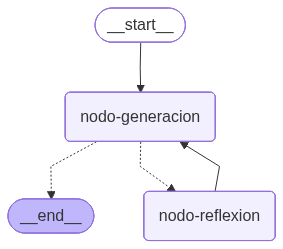

In [119]:
from IPython.display import Image, display

display(Image(flujo_trabajo.get_graph().draw_mermaid_png()))

Copyright © 2025 IBM Corporation. All rights reserved.
